# Local Gain–Loss Click Sequences Near a Domain Wall

This notebook loads the paired `raster_y` and `random` ten-trajectory campaigns, validates their metadata, and compares local gain/loss motifs near the two hard controller walls. The analysis is exploratory: it reports effect sizes and trajectory-bootstrap intervals without making asymptotic claims.

## Record and estimators

For every visited cell and controller channel, the measured occupation is compared with the target occupation. The signed reset transfer is $$Y=n_{\mathrm{after}}-n_{\mathrm{measured}}\in\{-1,0,+1\},$$ so negative/zero/positive values denote loss/none/gain. The A and B trial orbitals are respectively the $$+1$$ and $$-1$$ eigenvectors of the selected Pauli operator, which is fixed to $$X$$ here. Projecting both trial eigenvectors into the upper/lower band gives the four channels $$A+,A-,B+,B-.$$

A unit-cell sweep is encoded by four bits $$(A\text{-loss},A\text{-gain},B\text{-loss},B\text{-gain})$$ and hence one of 16 motifs. Temporal words join motifs at one cell across cycles; spatial words join motifs along the periodic $$y$$ ring. Shuffle nulls preserve one-point motif counts while destroying the tested order. All plotted sequence results use cycles after the recorded burn-in.

## Runtime and CPU allocation

Set `CLICK_CPU_RANGE` to a Linux CPU list such as `56-65` or `56,58,60`. Leave it empty to retain the current process affinity.

In [1]:
import os

CPU_RANGE = os.environ.get("CLICK_CPU_RANGE", "")

def parse_cpu_range(spec):
    cpus = set()
    for token in spec.split(","):
        token = token.strip()
        if not token:
            continue
        if "-" in token:
            start, stop = (int(value) for value in token.split("-", 1))
            cpus.update(range(start, stop + 1))
        else:
            cpus.add(int(token))
    return sorted(cpus)

if CPU_RANGE:
    requested_cpus = parse_cpu_range(CPU_RANGE)
    os.sched_setaffinity(0, requested_cpus)
else:
    requested_cpus = sorted(os.sched_getaffinity(0))
for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[variable] = "1"
print({"cpu_affinity": sorted(os.sched_getaffinity(0)), "single_thread_libraries": True})

{'cpu_affinity': [56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111], 'single_thread_libraries': True}


## Setup and campaign location

Set `CLICK_CAMPAIGN_ROOT` to a completed smoke or production campaign. By default, the newest campaign directory is selected.

In [2]:
from pathlib import Path
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
DEFAULT_PARENT = REPO_ROOT / "topological_frustration_diagnostics" / "results" / "local_gain_loss_clicks"
root_override = os.environ.get("CLICK_CAMPAIGN_ROOT", "").strip()
if root_override:
    CAMPAIGN_ROOT = Path(root_override).expanduser().resolve()
else:
    candidates = sorted(path for path in DEFAULT_PARENT.glob("*") if path.is_dir())
    if not candidates:
        raise FileNotFoundError("No campaign found; set CLICK_CAMPAIGN_ROOT explicitly.")
    CAMPAIGN_ROOT = candidates[-1]
FIGURE_DIR = Path(os.environ.get("CLICK_FIGURE_DIR", CAMPAIGN_ROOT / "notebook_figures")).resolve()
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_WIDTH = 3.375
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["CMU Sans Serif", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "mathtext.fontset": "cm",
    "figure.dpi": 150,
    "savefig.dpi": 300,
})
print({"campaign_root": str(CAMPAIGN_ROOT), "figure_dir": str(FIGURE_DIR)})

{'campaign_root': '/home/abhuiyan/class_A_fermionic_adaptive_circuit/topological_frustration_diagnostics/results/local_gain_loss_clicks/20260814_N20x24_S10_C48_production', 'figure_dir': '/home/abhuiyan/class_A_fermionic_adaptive_circuit/topological_frustration_diagnostics/results/local_gain_loss_clicks/20260814_N20x24_S10_C48_production/notebook_figures'}


## Load data and actual run parameters

The next cell discovers exactly one run directory per schedule, loads the dense and tidy records, and displays the parameters actually persisted by the campaign.

In [3]:
SCHEDULES = ("raster_y", "random")

def unique_path(root, name):
    matches = sorted(root.rglob(name))
    if len(matches) != 1:
        raise RuntimeError(f"Expected one {name} below {root}, found {len(matches)}")
    return matches[0]

data = {}
parameter_rows = []
for schedule in SCHEDULES:
    stage = CAMPAIGN_ROOT / schedule
    raw_path = unique_path(stage, "activity_raw.npz")
    run_dir = raw_path.parent
    with np.load(raw_path) as loaded:
        raw = {key: loaded[key] for key in loaded.files}
    with np.load(run_dir / "activity_analysis.npz") as loaded:
        activity = {key: loaded[key] for key in loaded.files}
    with np.load(run_dir / "click_sequence_analysis.npz") as loaded:
        sequence = {key: loaded[key] for key in loaded.files}
    summary = json.loads((run_dir / "run_summary.json").read_text())
    events = pd.read_parquet(run_dir / "click_events.parquet")
    motifs = pd.read_parquet(run_dir / "unit_cell_motifs.parquet")
    candidates = pd.read_csv(run_dir / "click_sequence_candidates.csv")
    data[schedule] = {
        "run_dir": run_dir,
        "raw": raw,
        "activity": activity,
        "sequence": sequence,
        "summary": summary,
        "events": events,
        "motifs": motifs,
        "candidates": candidates,
    }
    config = summary["config"]
    parameter_rows.append({
        "schedule": schedule,
        **{key: config[key] for key in (
            "Nx", "Ny", "samples", "cycles", "burn_in", "nshell", "alpha_1", "alpha_2",
            "DW", "dw_truncation", "meas_slab_only", "trial_orbitals", "protocol", "random_seed"
        )},
        "sample_seeds_match_pair": None,
    })
seed_match = data["raster_y"]["summary"]["sample_seeds"] == data["random"]["summary"]["sample_seeds"]
for row in parameter_rows:
    row["sample_seeds_match_pair"] = seed_match
parameters = pd.DataFrame(parameter_rows)
display(parameters)

,schedule,Nx,Ny,samples,cycles,burn_in,nshell,alpha_1,alpha_2,DW,dw_truncation,meas_slab_only,trial_orbitals,protocol,random_seed,sample_seeds_match_pair
0,raster_y,20,24,10,48,24,1,1,30,True,True,True,X,perfect_correction,20260814,True
1,random,20,24,10,48,24,1,1,30,True,True,True,X,perfect_correction,20260814,True


## Representative click raster

This plot shows the four signed click types at the left hard wall for one trajectory. It exposes burst structure directly before any averaging.

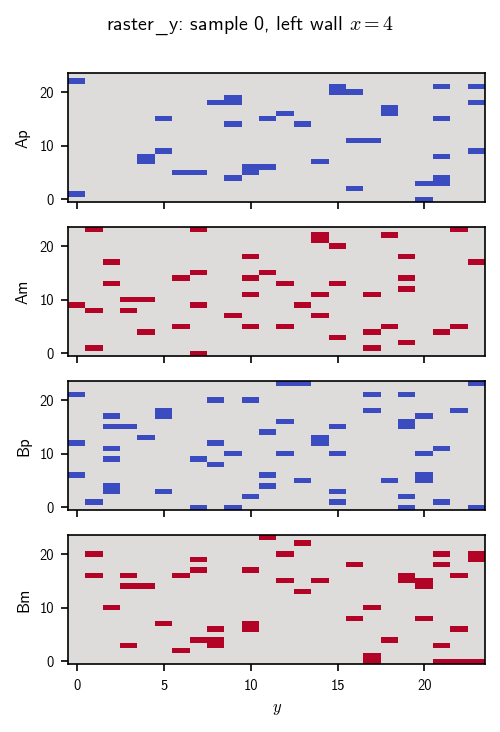

In [4]:
schedule = "raster_y"
frame = data[schedule]["events"]
burn_in = int(data[schedule]["sequence"]["burn_in"])
wall_x = int(data[schedule]["raw"]["wall_x"][0])
selected = frame[(frame["sample"] == 0) & (frame["cycle"] > burn_in) & (frame["x"] == wall_x)]
channels = ("Ap", "Am", "Bp", "Bm")
fig, axes = plt.subplots(4, 1, figsize=(FIGURE_WIDTH, 4.8), sharex=True, sharey=True)
for axis, channel in zip(axes, channels):
    block = selected[selected["channel"] == channel].pivot(index="cycle", columns="y", values="transfer")
    axis.imshow(block.to_numpy(), aspect="auto", origin="lower", cmap="coolwarm", vmin=-1, vmax=1)
    axis.set_ylabel(channel)
axes[-1].set_xlabel(r"$y$")
fig.suptitle(f"{schedule}: sample 0, left wall $x={wall_x}$", y=1.0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "representative_click_raster.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "representative_click_raster.pdf", bbox_inches="tight")
plt.show()

## Channel-resolved transverse activity

The post-burn-in absolute-transfer probability is plotted across $$x$$. A wall-localized controller frustration signal should peak near the two recorded wall columns.

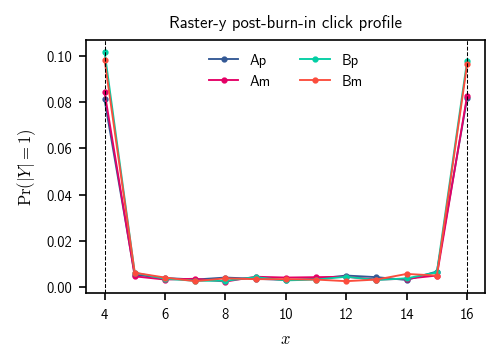

In [5]:
fig, axis = plt.subplots(figsize=(FIGURE_WIDTH, 2.45))
colors = ("#345995", "#E40066", "#03CEA4", "#FB4D3D")
activity = data["raster_y"]["activity"]
for index, (channel, color) in enumerate(zip(channels, colors)):
    axis.plot(activity["spatial_profile_x"][1, :, index], marker="o", ms=2, lw=0.9, color=color, label=channel)
for wall in data["raster_y"]["raw"]["wall_x"]:
    axis.axvline(int(wall), color="black", lw=0.5, ls="--")
axis.set(xlabel=r"$x$", ylabel=r"$\Pr(|Y|=1)$", title="Raster-y post-burn-in click profile")
axis.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "channel_activity_profile.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "channel_activity_profile.pdf", bbox_inches="tight")
plt.show()

## Unit-cell motif population

The 16 motif frequencies compare the pooled interface with the active slab interior. Motif zero is the no-click state; multi-click motifs retain simultaneous A/B gain/loss events.

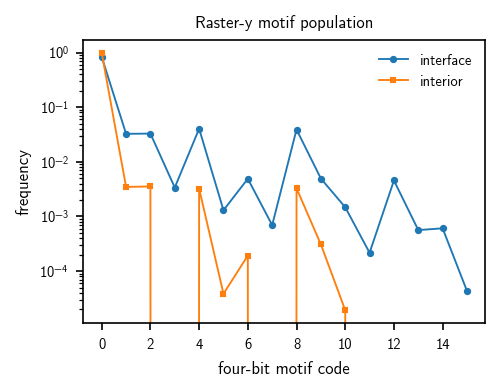

In [6]:
sequence = data["raster_y"]["sequence"]
region_names = [str(value) for value in sequence["region_names"]]
interface_index = region_names.index("interface")
interior_index = region_names.index("interior")
fig, axis = plt.subplots(figsize=(FIGURE_WIDTH, 2.65))
x = np.arange(16)
axis.plot(x, sequence["motif_frequency"][interface_index], marker="o", ms=2.5, lw=0.9, label="interface")
axis.plot(x, sequence["motif_frequency"][interior_index], marker="s", ms=2.2, lw=0.9, label="interior")
axis.set(xlabel="four-bit motif code", ylabel="frequency", xticks=np.arange(0, 16, 2), title="Raster-y motif population")
axis.set_yscale("log")
axis.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "motif_population.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "motif_population.pdf", bbox_inches="tight")
plt.show()

## Temporal pair enrichment

Each heat map is the interface log-two enrichment of a motif transition over the within-cell cycle-permutation null. Persistence across both schedules is stronger evidence than a raster-only transition.

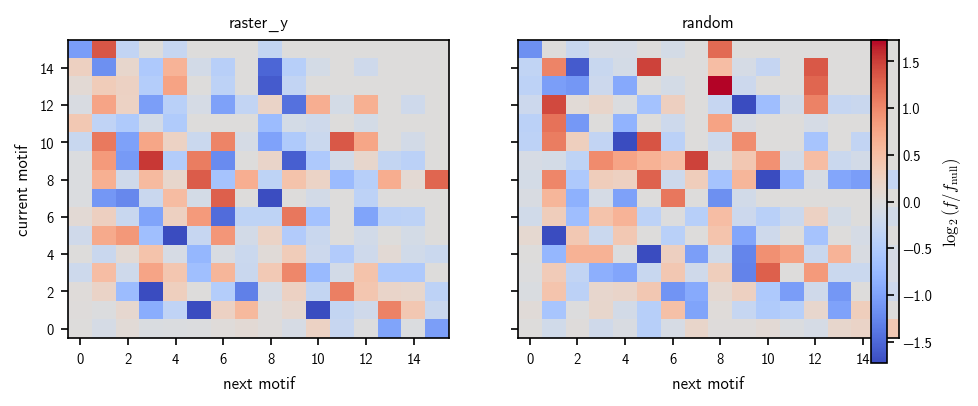

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(2 * FIGURE_WIDTH, 2.8), sharex=True, sharey=True)
limit = 0.0
blocks = []
for schedule in SCHEDULES:
    seq = data[schedule]["sequence"]
    regions = [str(value) for value in seq["region_names"]]
    block = seq["temporal_pair_log2_enrichment"][regions.index("interface")].reshape(16, 16)
    blocks.append(block)
    limit = max(limit, float(np.nanpercentile(np.abs(block), 98)))
limit = max(limit, 0.25)
for axis, schedule, block in zip(axes, SCHEDULES, blocks):
    image = axis.imshow(block, origin="lower", cmap="coolwarm", vmin=-limit, vmax=limit, aspect="auto")
    axis.set(title=schedule, xlabel="next motif")
axes[0].set_ylabel("current motif")
fig.colorbar(image, ax=axes, label=r"$\log_2(f/f_{\rm null})$", fraction=0.035)
fig.subplots_adjust(left=0.08, right=0.9, bottom=0.17, top=0.88, wspace=0.18)
fig.savefig(FIGURE_DIR / "temporal_pair_enrichment.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "temporal_pair_enrichment.pdf", bbox_inches="tight")
plt.show()

## Spatial pair enrichment

These matrices use periodic nearest-neighbor words $$m(y)\to m(y+1)$$ and compare them with independent permutations around each $$y$$ ring.

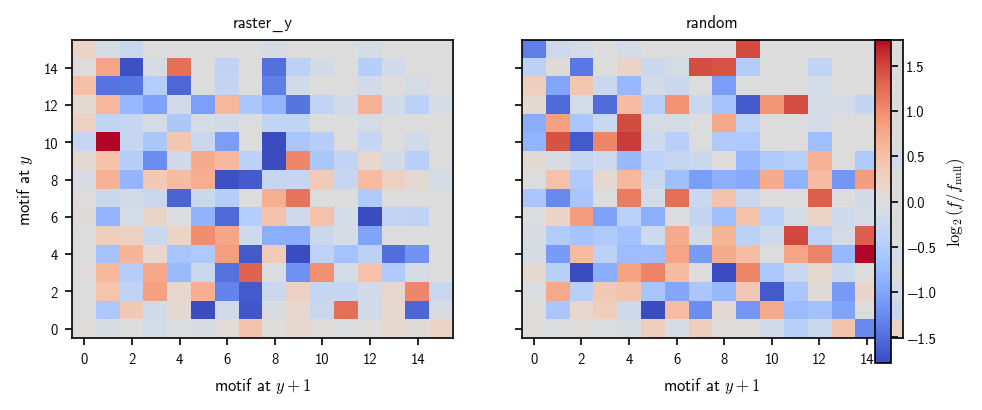

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(2 * FIGURE_WIDTH, 2.8), sharex=True, sharey=True)
limit = 0.0
blocks = []
for schedule in SCHEDULES:
    seq = data[schedule]["sequence"]
    regions = [str(value) for value in seq["region_names"]]
    block = seq["spatial_pair_log2_enrichment"][regions.index("interface")].reshape(16, 16)
    blocks.append(block)
    limit = max(limit, float(np.nanpercentile(np.abs(block), 98)))
limit = max(limit, 0.25)
for axis, schedule, block in zip(axes, SCHEDULES, blocks):
    image = axis.imshow(block, origin="lower", cmap="coolwarm", vmin=-limit, vmax=limit, aspect="auto")
    axis.set(title=schedule, xlabel=r"motif at $y+1$")
axes[0].set_ylabel(r"motif at $y$")
fig.colorbar(image, ax=axes, label=r"$\log_2(f/f_{\rm null})$", fraction=0.035)
fig.subplots_adjust(left=0.08, right=0.9, bottom=0.17, top=0.88, wspace=0.18)
fig.savefig(FIGURE_DIR / "spatial_pair_enrichment.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "spatial_pair_enrichment.pdf", bbox_inches="tight")
plt.show()

## Raster-versus-random motif comparison

A motif that remains near the diagonal has similar interface frequency under both visitation schedules. Strong deviations identify schedule-conditioned populations.

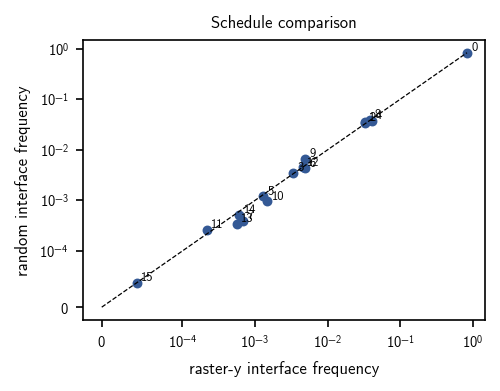

In [9]:
raster_seq = data["raster_y"]["sequence"]
random_seq = data["random"]["sequence"]
raster_regions = [str(value) for value in raster_seq["region_names"]]
random_regions = [str(value) for value in random_seq["region_names"]]
raster_frequency = raster_seq["motif_frequency"][raster_regions.index("interface")]
random_frequency = random_seq["motif_frequency"][random_regions.index("interface")]
fig, axis = plt.subplots(figsize=(FIGURE_WIDTH, 2.65))
axis.scatter(raster_frequency, random_frequency, s=14, color="#345995")
for motif_code, (x_value, y_value) in enumerate(zip(raster_frequency, random_frequency)):
    axis.annotate(str(motif_code), (x_value, y_value), xytext=(2, 1), textcoords="offset points", fontsize=6)
maximum = float(max(np.max(raster_frequency), np.max(random_frequency)))
axis.plot([0, maximum], [0, maximum], color="black", lw=0.6, ls="--")
axis.set(xlabel="raster-y interface frequency", ylabel="random interface frequency", title="Schedule comparison")
axis.set_xscale("symlog", linthresh=1e-4)
axis.set_yscale("symlog", linthresh=1e-4)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "schedule_motif_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "schedule_motif_comparison.pdf", bbox_inches="tight")
plt.show()

## Supported pair and triplet candidates

The tables retain words with at least the configured support. The `candidate` flag means the exploratory 95% trajectory-bootstrap interval excludes zero enrichment; it is not a multiple-testing-corrected discovery claim.

In [10]:
candidate_tables = []
for schedule in SCHEDULES:
    frame = data[schedule]["candidates"].copy()
    if "schedule" not in frame.columns:
        frame.insert(0, "schedule", schedule)
    candidate_tables.append(frame)
ranked_candidates = pd.concat(candidate_tables, ignore_index=True)
ranked_candidates = ranked_candidates.sort_values(
    ["candidate", "log2_enrichment", "count"],
    ascending=[False, False, False],
)
display(ranked_candidates.head(30))

,schedule,family,region,word_code,motif_codes,motif_labels,count,null_frequency,log2_enrichment,ci_low,ci_high,candidate
742,random,temporal_triplet,all,2064,8-1-0,B_gain -> A_loss -> none,77,0.000522,1.069833,0.589775,1.585413,True
743,random,temporal_pair,left_wall,129,8-1,B_gain -> A_loss,54,0.002332,1.065139,0.604566,1.732524,True
744,random,temporal_triplet,interface,2064,8-1-0,B_gain -> A_loss -> none,75,0.001564,1.058894,0.579961,1.585397,True
745,random,temporal_triplet,left_wall,2064,8-1-0,B_gain -> A_loss -> none,35,0.001357,1.052726,0.329276,1.901820,True
746,random,temporal_triplet,right_wall,2064,8-1-0,B_gain -> A_loss -> none,40,0.001557,1.045082,0.395634,1.831877,True
747,random,temporal_triplet,all,129,0-8-1,none -> B_gain -> A_loss,75,0.000521,1.034342,0.522507,1.622233,True
748,random,temporal_pair,all,129,8-1,B_gain -> A_loss,113,0.000774,1.029302,0.694840,1.413614,True
749,random,temporal_triplet,interface,129,0-8-1,none -> B_gain -> A_loss,73,0.001561,1.022711,0.503336,1.623735,True
750,random,temporal_pair,interface,129,8-1,B_gain -> A_loss,111,0.002472,1.022376,0.694840,1.421243,True
751,random,temporal_triplet,right_wall,129,0-8-1,none -> B_gain -> A_loss,39,0.001544,1.020674,0.349943,1.874753,True


## Raw summary and diagnostics

The final cell prints shapes, null/bootstrap counts, completeness checks, and run-level scalar metrics used by the plots.

In [11]:
diagnostics = {}
for schedule in SCHEDULES:
    raw = data[schedule]["raw"]
    seq = data[schedule]["sequence"]
    summary = data[schedule]["summary"]
    valid = raw["valid"]
    diagnostics[schedule] = {
        "raw_transfer_shape": tuple(raw["transfer_Y"].shape),
        "all_visits_valid": bool(np.all(valid)),
        "perfect_correction_identity": bool(np.array_equal(raw["defect_X"], np.abs(raw["transfer_Y"]))),
        "finite_success_probabilities": int(np.count_nonzero(np.isfinite(raw["success_probability"][valid]))),
        "permutations": int(seq["permutation_count"]),
        "bootstraps": int(seq["bootstrap_count"]),
        "minimum_support": int(seq["minimum_support"]),
        "candidate_rows": int(np.count_nonzero(data[schedule]["candidates"].get("candidate", False))),
        "metrics": summary["metrics"],
    }
print(json.dumps(diagnostics, indent=2, default=str))

{
  "raster_y": {
    "raw_transfer_shape": [
      10,
      48,
      312,
      4
    ],
    "all_visits_valid": true,
    "perfect_correction_identity": true,
    "finite_success_probabilities": 599040,
    "permutations": 1000,
    "bootstraps": 1000,
    "minimum_support": 20,
    "candidate_rows": 44,
    "metrics": {
      "perfect_correction_identity": true,
      "sequence_candidate_words": 44,
      "sequence_supported_words": 740,
      "total_abs_transfer": 13306,
      "total_defects": 13306
    }
  },
  "random": {
    "raw_transfer_shape": [
      10,
      48,
      312,
      4
    ],
    "all_visits_valid": true,
    "perfect_correction_identity": true,
    "finite_success_probabilities": 599040,
    "permutations": 1000,
    "bootstraps": 1000,
    "minimum_support": 20,
    "candidate_rows": 83,
    "metrics": {
      "perfect_correction_identity": true,
      "sequence_candidate_words": 83,
      "sequence_supported_words": 700,
      "total_abs_transfer": 13516,
